In [2]:
import torch
from torch import nn
import torch.nn.functional as F


class ChannelMLP(nn.Module):
    """ChannelMLP applies an arbitrary number of layers of 
    1d convolution and nonlinearity to the channels of input
    and is invariant to spatial resolution.

    Parameters
    ----------
    in_channels : int
    out_channels : int, default is None
        if None, same is in_channels
    hidden_channels : int, default is None
        if None, same is in_channels
    n_layers : int, default is 2
        number of linear layers in the MLP
    non_linearity : default is F.gelu
    dropout : float, default is 0
        if > 0, dropout probability
    """

    def __init__(
        self,
        in_channels,
        out_channels=None,
        hidden_channels=None,
        n_layers=2,
        n_dim=2,
        non_linearity=F.gelu,
        dropout=0.0,
        **kwargs,
    ):
        super().__init__()
        self.n_layers = n_layers
        self.in_channels = in_channels
        self.out_channels = in_channels if out_channels is None else out_channels
        self.hidden_channels = (
            in_channels if hidden_channels is None else hidden_channels
        )
        self.non_linearity = non_linearity
        self.dropout = (
            nn.ModuleList([nn.Dropout(dropout) for _ in range(n_layers)])
            if dropout > 0.0
            else None
        )
        
        # we use nn.Conv1d for everything and roll data along the 1st data dim
        self.fcs = nn.ModuleList()
        for i in range(n_layers):
            if i == 0 and i == (n_layers - 1):
                self.fcs.append(nn.Conv1d(self.in_channels, self.out_channels, 1))
            elif i == 0:
                self.fcs.append(nn.Conv1d(self.in_channels, self.hidden_channels, 1))
            elif i == (n_layers - 1):
                self.fcs.append(nn.Conv1d(self.hidden_channels, self.out_channels, 1))
            else:
                self.fcs.append(nn.Conv1d(self.hidden_channels, self.hidden_channels, 1))

    def forward(self, x):
        reshaped = False
        size = list(x.shape)
        if x.ndim > 3:  
            # batch, channels, x1, x2... extra dims
            # .reshape() is preferable but .view()
            # cannot be called on non-contiguous tensors
            x = x.reshape((*size[:2], -1)) 
            reshaped = True

        for i, fc in enumerate(self.fcs):
            x = fc(x)
            if i < self.n_layers - 1:
                x = self.non_linearity(x)
            if self.dropout is not None:
                x = self.dropout[i](x)

        # if x was an N-d tensor reshaped into 1d, undo the reshaping
        # same logic as above: .reshape() handles contiguous tensors as well
        if reshaped:
            x = x.reshape((size[0], self.out_channels, *size[2:]))

        return x

In [5]:
channels = 1
batch = 4
x_dim = 20
# y_dim = 256
# z_dim = 10
x = torch.rand((batch, channels, x_dim,))
model = ChannelMLP(in_channels=channels, out_channels=4, hidden_channels=16, n_layers=4)
y = model(x)
y.shape

torch.Size([4, 4, 20])

In [6]:
y = model(torch.rand((batch, channels, x_dim)))
y.shape

torch.Size([4, 4, 20])

In [6]:
import h5py
import matplotlib.pyplot as plt

path = "/Users/anthonypoole/test/hw2d_sim_step0.025_end1_pts512_c11_k015_N3_nu5e-8_20250205112738_5501_0.h5"
file = h5py.File(path, 'r')
print(file.attrs['dx'])
gamma_n = file['gamma_n'][:]
plt.plot(gamma_n)
plt.show()

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '/Users/anthonypoole/test/hw2d_sim_step0.025_end1_pts512_c11_k015_N3_nu5e-8_20250205112738_5501_0.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

0.0818123086872342


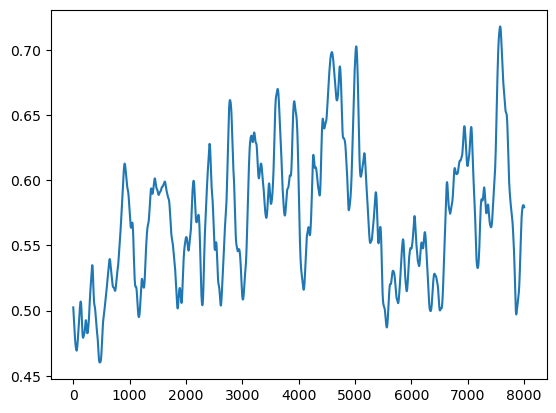

In [7]:
import h5py
import matplotlib.pyplot as plt

path = "/Users/anthonypoole/data/local_dqfno/train/hw2d_sim_step0.025_end1_pts512_c11_k015_N3_nu5e-8_20250205112739_27514_2.h5"
file = h5py.File(path, 'r')
print(file.attrs['dx'])
gamma_n = file['gamma_n'][:]
plt.plot(gamma_n)
plt.show()

0.0818123086872342


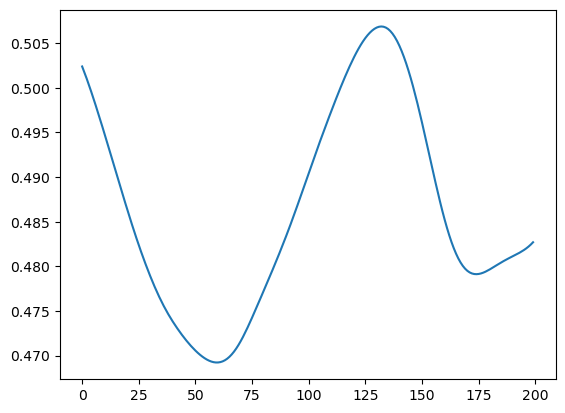

In [9]:
import h5py
import matplotlib.pyplot as plt

path = "/Users/anthonypoole/data/local_dqfno/train/chunked/input_000000.h5"
file = h5py.File(path, 'r')
print(file.attrs['dx'])
gamma_n = file['gamma_n'][:]
plt.plot(gamma_n)
plt.show()